<a href="https://colab.research.google.com/github/aleakucing/Pembelajaran-Memsin/blob/main/JS05/JS05_Assigment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
#1 : load data
import numpy as np
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/PemMes/JS5/voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [11]:
df.info()
df.describe()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,count
label,
male,1584
female,1584


In [12]:
# 2.a : Inspeksi Data
print(df.info())
print('\nDistribusi Label:')
print(df['label'].value_counts())
print('\n' + '='*40 + '\n')

# 2.b : Encoding Label
new_labels = {
    'female': 0,
    'male': 1
}

df['label'] = df['label'].map(new_labels)
df.head()

# 2.c : Split Data
X = df.drop('label', axis=1)
y = df['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Train: {len(X_train)}")
print(f"Jumlah Data Test: {len(X_test)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [13]:
# 3 : Cek Korelasi Fitur Terhadap Label
korelasi = df.corr()['label'].abs().sort_values(ascending=False)
print("Peringkat Fitur Berdasarkan Korelasi Tertinggi Terhadap Label:")
print(korelasi)

Peringkat Fitur Berdasarkan Korelasi Tertinggi Terhadap Label:
label       1.000000
meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
meanfreq    0.337415
centroid    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label, dtype: float64


In [14]:
# 4 : Ekstraksi Fitur dan Standarisasi
fitur_terpilih = ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm']

X_train_sub = X_train[fitur_terpilih]
X_test_sub = X_test[fitur_terpilih]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test_sub)

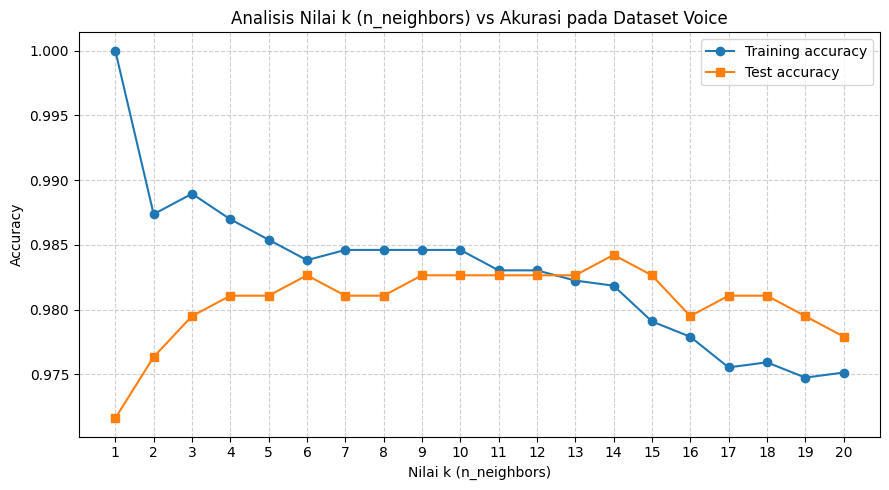

In [15]:
# 5 : Eksperimen Nilai k (1 sampai 20) dan Plot Grafik
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

training_accuracy = []
test_accuracy = []

k_settings = range(1, 21)

for k in k_settings:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    training_accuracy.append(knn.score(X_train_scaled, y_train))
    test_accuracy.append(knn.score(X_test_scaled, y_test))

# Visualisasi Grafik Nilai k vs Akurasi
plt.figure(figsize=(9, 5))
plt.plot(k_settings, training_accuracy, label="Training accuracy", marker='o')
plt.plot(k_settings, test_accuracy, label="Test accuracy", marker='s')
plt.title("Analisis Nilai k (n_neighbors) vs Akurasi pada Dataset Voice")
plt.ylabel("Accuracy")
plt.xlabel("Nilai k (n_neighbors)")
plt.xticks(list(k_settings))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# 6 : Evaluasi Model Terbaik (k = 3)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_terbaik = KNeighborsClassifier(n_neighbors=3)
knn_terbaik.fit(X_train_scaled, y_train)

y_pred = knn_terbaik.predict(X_test_scaled)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['female', 'male']))

Akurasi Model: 0.9794952681388013
Confusion Matrix:
[[294   3]
 [ 10 327]]
Laporan Klasifikasi:
              precision    recall  f1-score   support

      female       0.97      0.99      0.98       297
        male       0.99      0.97      0.98       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

